<a href="https://colab.research.google.com/github/seojoon1/2026_bigdatacomputing/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2차 프로그래밍 과제: 다중 특성 회귀 파이프라인 + Streamlit 배포
**기대수명(Life expectancy) 예측 | 독립변수: Adult mortality, BMI, GDP (Schooling 제외)**

> Colab에서 위에서부터 순서대로 실행하세요.

## STEP 0. 라이브러리 설치

In [1]:
!pip install -q scikit-learn pandas joblib matplotlib streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 48.1 MB/s eta 0:00:00


## STEP 1. 데이터 준비 · 모델 3종 학습 · `.pkl` 저장
- 80/20 분할 후 **훈련은 무작위 50개 샘플만** 사용해 과적합을 유도
- Pipeline: `StandardScaler` → `PolynomialFeatures` → 회귀모델

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1) 데이터 로드 + 결측치 제거
URL = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(URL)
df.columns = df.columns.str.strip()   # 컬럼명 앞뒤 공백 제거 (이 데이터셋 주의점)
df = df.dropna()

# 2) 특성 선택 (Schooling 사용 금지, 3개 이상)
FEATURES = ["Adult mortality", "BMI", "GDP"]
TARGET   = "Life expectancy"

X = df[FEATURES]
y = df[TARGET]

# 3) 80/20 분할
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) 과대적합 관찰을 위해 훈련 데이터는 무작위 50개만 사용
train_sample = X_train_full.sample(n=50, random_state=42)
X_train = train_sample
y_train = y_train_full.loc[train_sample.index]

print("훈련 샘플:", X_train.shape, " / 테스트:", X_test.shape)

훈련 샘플: (50, 3)  / 테스트: (330, 3)


In [3]:
# 라이브러리 import (런타임 새로 켜도 동작)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
import joblib

# 모델 3종 정의
models = {
    'Linear': Pipeline([('scaler', StandardScaler()),
                        ('poly', PolynomialFeatures(degree=1)),
                        ('reg', LinearRegression())]),
    'Poly':   Pipeline([('scaler', StandardScaler()),
                        ('poly', PolynomialFeatures(degree=3)),
                        ('reg', LinearRegression())]),       # 규제 없음 → 과적합
    'Ridge':  Pipeline([('scaler', StandardScaler()),
                        ('poly', PolynomialFeatures(degree=3)),
                        ('reg', Ridge(alpha=1.0))]),         # 릿지 규제
}

# 학습 + pkl 저장 + 성능 확인
for name, m in models.items():
    m.fit(X_train, y_train)
    joblib.dump(m, f'model_{name}.pkl')
    tr = r2_score(y_train, m.predict(X_train))
    te = r2_score(y_test, m.predict(X_test))
    print(f'{name:6} 저장완료 | Train R2={tr:.3f}  Test R2={te:.3f}')

Linear 저장완료 | Train R2=0.729  Test R2=0.570
Poly   저장완료 | Train R2=0.901  Test R2=-4.903
Ridge  저장완료 | Train R2=0.880  Test R2=0.639


## STEP 2. 성능 비교 미리보기 (노트북 내 확인용)
Poly는 Train R²는 높지만 Test R²가 급락 → 과적합. Ridge가 일반화 성능을 회복.

In [4]:
rows = []
for name, m in models.items():
    rows.append({
        'Model': name,
        'Train R2': round(r2_score(y_train, m.predict(X_train)), 3),
        'Test R2': round(r2_score(y_test, m.predict(X_test)), 3),
        'Train MSE': round(mean_squared_error(y_train, m.predict(X_train)), 2),
        'Test MSE': round(mean_squared_error(y_test, m.predict(X_test)), 2),
        'Complexity': m.named_steps['poly'].n_output_features_,
    })
pd.DataFrame(rows).set_index('Model')

,Train R2,Test R2,Train MSE,Test MSE,Complexity
Model,,,,,
Linear,0.729,0.570,29.73,30.53,4
Poly,0.901,-4.903,10.88,419.25,20
Ridge,0.880,0.639,13.18,25.67,20


## STEP 3. `app.py` 생성
Streamlit 웹앱 파일을 작성합니다. (성능 비교 테이블/그래프 + 실시간 예측 UI)

In [5]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ─────────────────────────────────────────────────────────────
# 0. 공통 설정 (notebook의 학습 코드와 반드시 동일하게 유지!)
# ─────────────────────────────────────────────────────────────
FEATURES = ["Adult mortality", "BMI", "GDP"]   # 자율 선택 3개 (Schooling 금지)
TARGET = "Life expectancy"
DATA_URL = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
RANDOM_STATE = 42
TRAIN_SAMPLE_N = 50

st.set_page_config(page_title="기대수명 예측 서비스", layout="wide")


# ─────────────────────────────────────────────────────────────
# 1. 데이터 로드 + 학습/테스트 분할 (notebook과 동일 seed로 재현)
# ─────────────────────────────────────────────────────────────
@st.cache_data
def load_split():
    df = pd.read_csv(DATA_URL)
    df.columns = df.columns.str.strip()      # WHO 데이터셋 컬럼명 공백 제거
    df = df.dropna()
    X, y = df[FEATURES], df[TARGET]
    X_tr_full, X_te, y_tr_full, y_te = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    # 과적합 관찰용: 훈련은 무작위 50개만
    X_tr = X_tr_full.sample(n=TRAIN_SAMPLE_N, random_state=RANDOM_STATE)
    y_tr = y_tr_full.loc[X_tr.index]
    return df, X_tr, X_te, y_tr, y_te


@st.cache_resource
def load_models():
    return {name: joblib.load(f"model_{name}.pkl") for name in ["Linear", "Poly", "Ridge"]}


df, X_train, X_test, y_train, y_test = load_split()
models = load_models()


# ─────────────────────────────────────────────────────────────
# 2. 성능 평가지표 테이블
# ─────────────────────────────────────────────────────────────
def build_metrics():
    rows = []
    for name, m in models.items():
        pred_tr, pred_te = m.predict(X_train), m.predict(X_test)
        rows.append({
            "Model": name,
            "Train R²": round(r2_score(y_train, pred_tr), 3),
            "Test R²": round(r2_score(y_test, pred_te), 3),
            "Train MSE": round(mean_squared_error(y_train, pred_tr), 2),
            "Test MSE": round(mean_squared_error(y_test, pred_te), 2),
            "Complexity(특성수)": m.named_steps["poly"].n_output_features_,
        })
    return pd.DataFrame(rows).set_index("Model")


metrics_df = build_metrics()

# ─────────────────────────────────────────────────────────────
# 화면 구성
# ─────────────────────────────────────────────────────────────
st.title("🩺 다중 특성 회귀 모델 — 기대수명 예측")
st.caption(f"독립변수: {', '.join(FEATURES)} | 훈련 샘플 {TRAIN_SAMPLE_N}개 (과적합 유도)")

st.header("1️⃣ 모델 성능 비교")
col1, col2 = st.columns([1.3, 1])

with col1:
    st.subheader("성능 평가지표")
    st.dataframe(metrics_df, use_container_width=True)
    st.info("Poly(3차·규제X)는 Train R²↑ Test R²↓ → 과적합. Ridge가 규제로 일반화 성능을 잡아줍니다.")

with col2:
    st.subheader("Test R² 비교")
    fig, ax = plt.subplots(figsize=(5, 4))
    colors = ["#4C72B0", "#DD8452", "#55A868"]
    ax.bar(metrics_df.index, metrics_df["Test R²"], color=colors)
    ax.set_ylabel("Test R²")
    ax.set_title("Model Generalization (Test R²)")
    ax.axhline(0, color="gray", lw=0.8)
    for i, v in enumerate(metrics_df["Test R²"]):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom" if v >= 0 else "top")
    st.pyplot(fig)

st.divider()

# ─────────────────────────────────────────────────────────────
# 3. 실시간 예측 UI
# ─────────────────────────────────────────────────────────────
st.header("2️⃣ 실시간 기대수명 예측")

st.sidebar.header("⚙️ 입력값 조절")
user_input = {}
for feat in FEATURES:
    lo, hi = float(df[feat].min()), float(df[feat].max())
    mean = float(df[feat].mean())
    user_input[feat] = st.sidebar.slider(feat, lo, hi, mean)

choice = st.sidebar.selectbox("예측 모델 선택", ["Linear", "Poly", "Ridge"])

input_df = pd.DataFrame([user_input])[FEATURES]
pred = models[choice].predict(input_df)[0]

st.markdown(f"### 선택 모델: `{choice}`")
st.markdown(
    f"<h1 style='text-align:center;color:#2E86C1;'>예측 기대수명: {pred:.1f} 세</h1>",
    unsafe_allow_html=True,
)
st.write("입력값:", user_input)


Writing app.py


## STEP 4. ngrok 터널링으로 웹 서비스 배포
1. https://dashboard.ngrok.com 에서 **Authtoken** 발급 후 아래에 붙여넣기
2. 실행하면 `https://xxxx.ngrok-free.app` 공인 URL이 출력됩니다
3. **모바일/외부 PC로 그 URL에 접속한 화면(주소 보이게)을 캡처**해서 이 노트북 셀에 첨부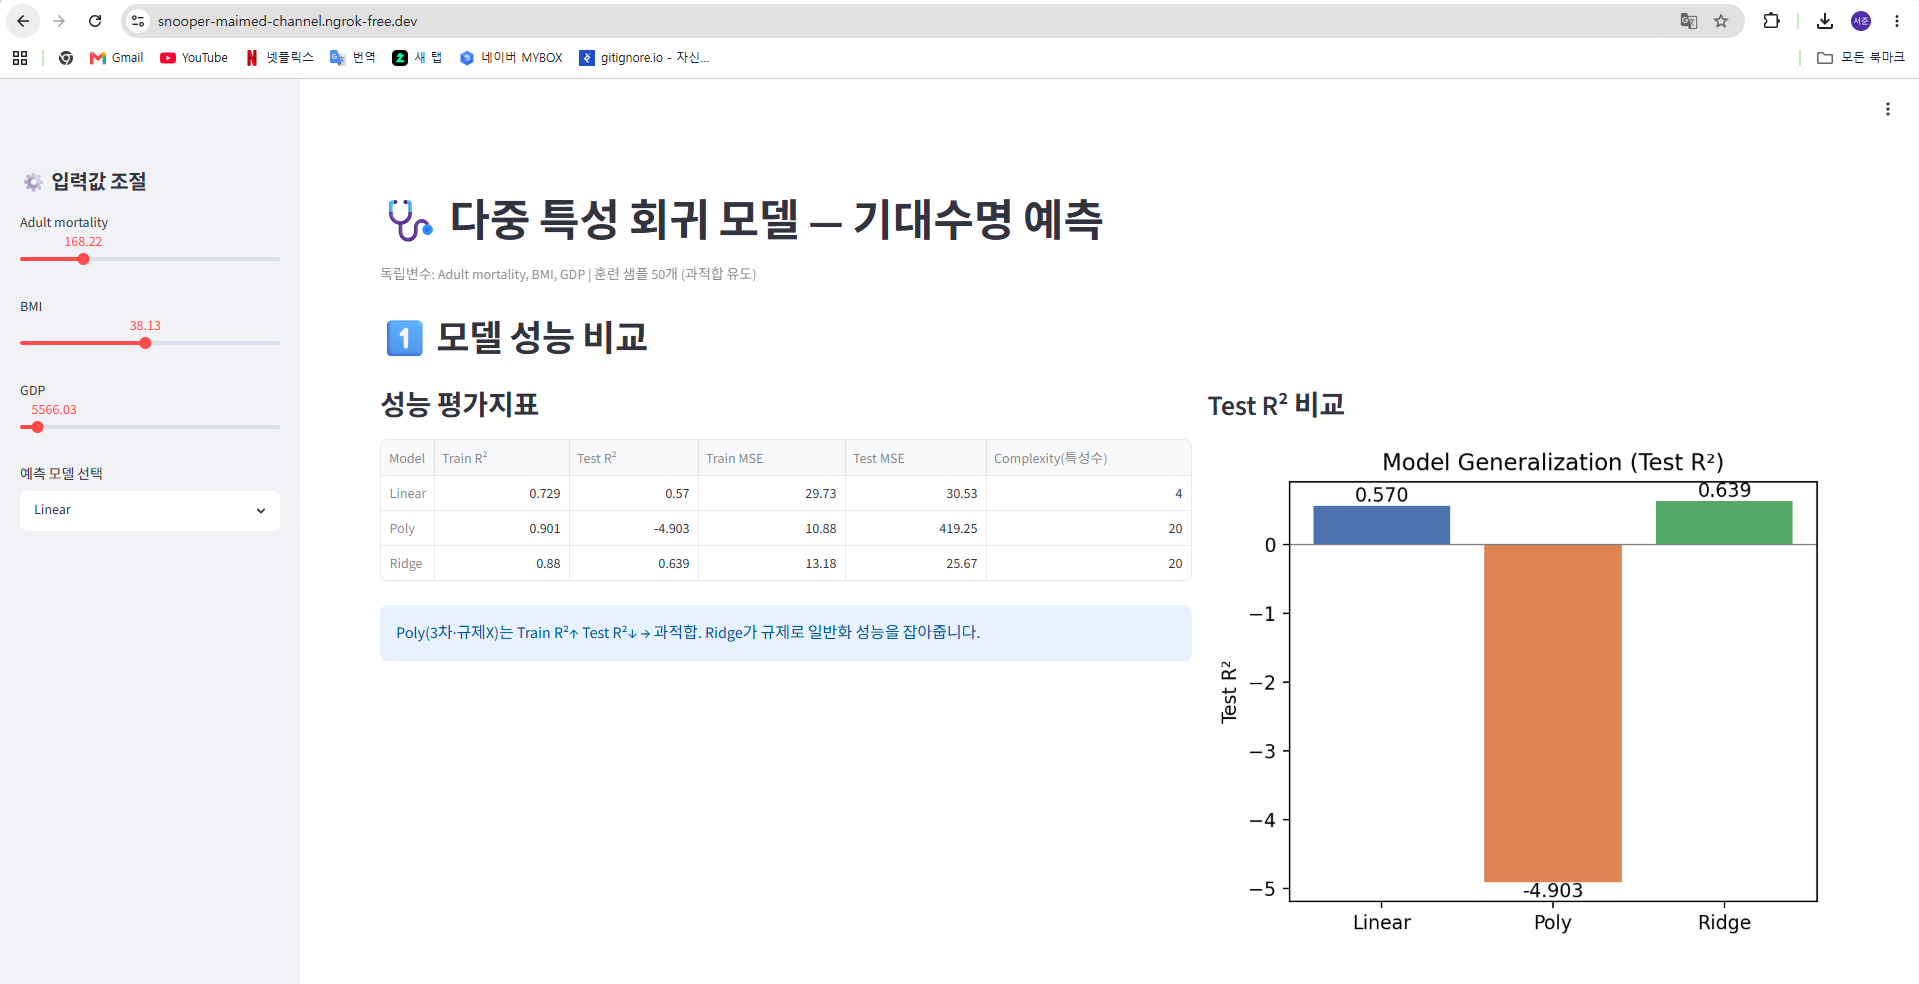

In [9]:
from pyngrok import ngrok
import time

NGROK_TOKEN = '3Et0fFoYH1ArvRe1NvVRCC9sfJa_3SQjTatPGEN5v4HmNmFKe'  # ← dashboard.ngrok.com 발급   # ← 본인 토큰 입력
ngrok.set_auth_token(NGROK_TOKEN)

# 기존 터널/프로세스 정리
ngrok.kill()
!pkill -f streamlit

# 백그라운드로 streamlit 실행 (포트 8501)
!streamlit run app.py --server.port 8501 &>/content/streamlit_log.txt &
time.sleep(5)

public_url = ngrok.connect(8501)
print('웹 서비스 접속 주소:', public_url)

웹 서비스 접속 주소: NgrokTunnel: "https://snooper-maimed-channel.ngrok-free.dev" -> "http://localhost:8501"


In [8]:
# (디버깅용) streamlit 로그 확인
!cat /content/streamlit_log.txt



2026-06-16 09:23:48.869 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.201.207.244:8501

